In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style = 'whitegrid', palette = 'muted')

df_bmw = pd.read_csv(r'/content/BMW_Cars_Pakistan.csv')

df_bmw.info()

df_bmw.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       344 non-null    int64  
 1   Car Name         344 non-null    object 
 2   Auction Rating   27 non-null     float64
 3   Model Year       344 non-null    int64  
 4   Mileage          344 non-null    int64  
 5   Fuel Type        344 non-null    object 
 6   Engine Capacity  344 non-null    float64
 7   Transmission     344 non-null    object 
 8   Engine Unit      344 non-null    object 
 9   Price (PKR)      297 non-null    float64
dtypes: float64(3), int64(3), object(4)
memory usage: 27.0+ KB


,Unnamed: 0,Car Name,Auction Rating,Model Year,Mileage,Fuel Type,Engine Capacity,Transmission,Engine Unit,Price (PKR)
0,0,BMW 7 Series 5th (F01) Generation 2013 ActiveH...,NaN,2013,52000,Hybrid,3000.0,Automatic,cc,NaN
1,1,BMW X5 2012 xDrive50i for Sale,8.0,2012,102148,Petrol,4400.0,Automatic,cc,16000000.0
2,2,BMW 7 Series 2017 740 Le xDrive for Sale,NaN,2017,48000,Hybrid,2000.0,Automatic,cc,34500000.0
3,3,BMW 2 Series 2021 218i Gran Coupe for Sale,9.3,2021,68064,Petrol,1500.0,Manual,cc,13500000.0
4,4,BMW X1 2017 sDrive18i A/T for Sale,8.6,2017,138928,Petrol,1500.0,Automatic,cc,8200000.0


Data Cleaning & Preprocessing

In [2]:
df_clean = df_bmw.copy()

df_clean = df_clean.drop(columns = ['Unnamed: 0', 'Auction Rating'])

df_clean = df_clean.dropna(subset = ['Price (PKR)'])

duplicates_count = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates()

df_clean.reset_index(drop = True, inplace = True)

In [3]:
print(f"Number of duplicate rows removed: {duplicates_count}")
print("/n--- Missing values after cleaning ---")
print(df_clean.isnull().sum())

print(f"\n--- Final Dataset Shape ---")
print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")

print("\n--- First 3 Rows of Cleaned Data ---")
print(df_clean.head(3))

Number of duplicate rows removed: 69
/n--- Missing values after cleaning ---
Car Name           0
Model Year         0
Mileage            0
Fuel Type          0
Engine Capacity    0
Transmission       0
Engine Unit        0
Price (PKR)        0
dtype: int64

--- Final Dataset Shape ---
Rows: 228, Columns: 8

--- First 3 Rows of Cleaned Data ---
                                      Car Name  Model Year  Mileage Fuel Type  \
0              BMW X5  2012 xDrive50i for Sale        2012   102148    Petrol   
1    BMW 7 Series  2017 740 Le xDrive for Sale        2017    48000    Hybrid   
2  BMW 2 Series  2021 218i Gran Coupe for Sale        2021    68064    Petrol   

   Engine Capacity Transmission Engine Unit  Price (PKR)  
0           4400.0    Automatic          cc   16000000.0  
1           2000.0    Automatic          cc   34500000.0  
2           1500.0       Manual          cc   13500000.0  


 Exploratory Data Analysis (EDA): Target & Numerical Features

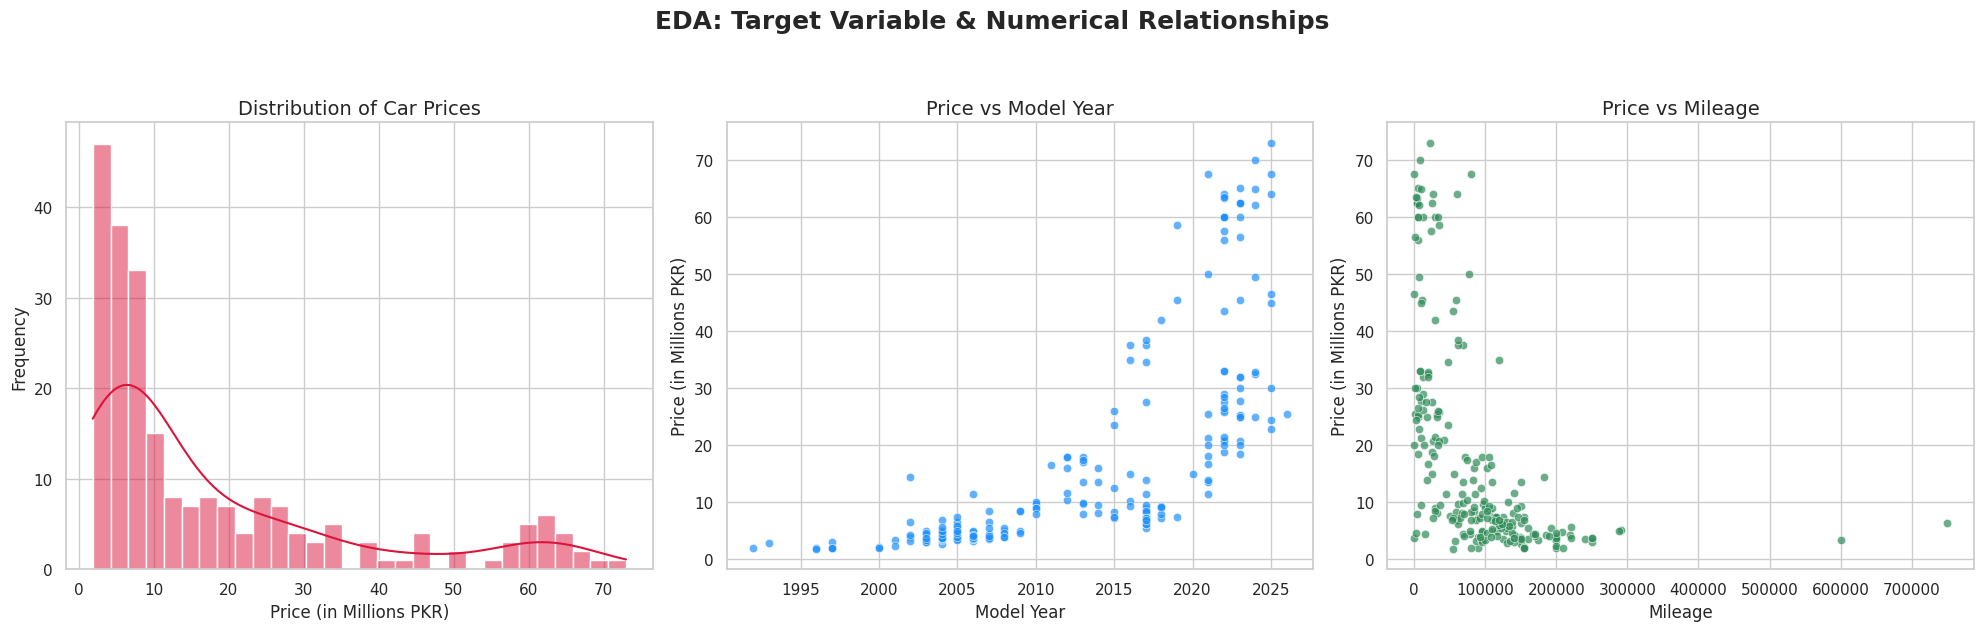

--- Correlation with Price (PKR) ---
Price_Millions     1.000000
Price (PKR)        1.000000
Model Year         0.697143
Engine Capacity   -0.488476
Mileage           -0.506491
Name: Price (PKR), dtype: float64


In [4]:
df_clean['Price_Millions'] = df_clean['Price (PKR)'] / 1000000

fig, axes = plt.subplots(1, 3, figsize = (20,6))
fig.suptitle('EDA: Target Variable & Numerical Relationships', fontsize = 18, fontweight = 'bold', y = 1.05)


sns.histplot(df_clean['Price_Millions'], kde = True, ax = axes[0], color = 'crimson', bins = 30)
axes[0].set_title('Distribution of Car Prices', fontsize = 14 )
axes[0].set_xlabel('Price (in Millions PKR)')
axes[0].set_ylabel('Frequency')


sns.scatterplot(data = df_clean, x = 'Model Year', y = 'Price_Millions', ax = axes[1], color = 'dodgerblue', alpha = 0.7)
axes[1].set_title('Price vs Model Year', fontsize = 14)
axes[1].set_xlabel('Model Year')
axes[1].set_ylabel('Price (in Millions PKR)')

sns.scatterplot(data = df_clean, x = 'Mileage', y = 'Price_Millions', ax = axes[2], color = 'seagreen', alpha = 0.7)
axes[2].set_title('Price vs Mileage', fontsize = 14)
axes[2].set_xlabel('Mileage')
axes[2].set_ylabel('Price (in Millions PKR)')

plt.tight_layout()
plt.show()

print("--- Correlation with Price (PKR) ---")
numeric_cols = df_clean.select_dtypes(include = [np.number]).columns.tolist()
correlation_matrix = df_clean[numeric_cols].corr()
print(correlation_matrix['Price (PKR)'].sort_values(ascending = False))

Exploratory Data Analysis (EDA): Categorical Features

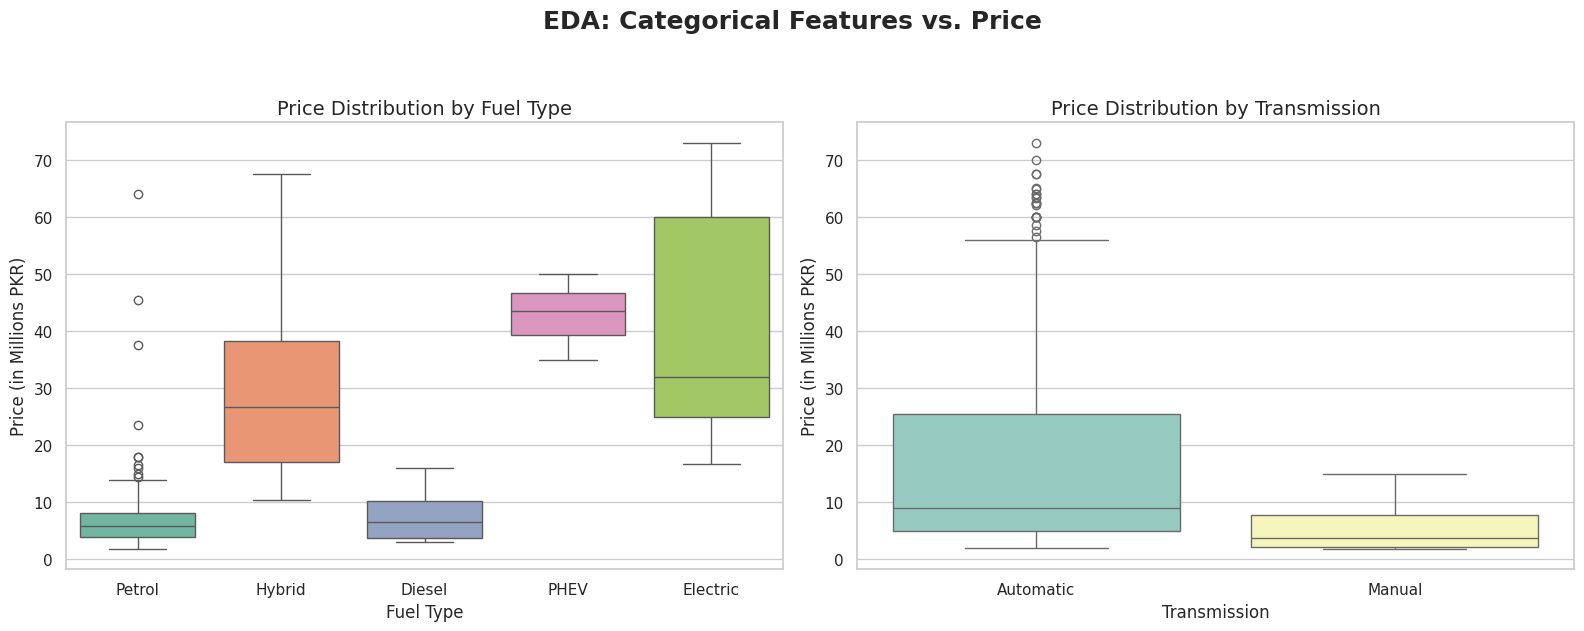

--- Fuel Type Distribution ---
Fuel Type
Petrol      135
Electric     59
Diesel       17
Hybrid       14
PHEV          3
Name: count, dtype: int64

--- Transmission Distribution ---
Transmission
Automatic    213
Manual        15
Name: count, dtype: int64

--- Engine Unit Distribution ---
Engine Unit
cc     169
kWh     59
Name: count, dtype: int64


In [5]:
fig, axes = plt.subplots(1, 2, figsize = (16,6) )
fig.suptitle('EDA: Categorical Features vs. Price', fontsize = 18, fontweight = 'bold', y = 1.05)

sns.boxplot(data = df_clean, x = 'Fuel Type', y = 'Price_Millions', ax = axes[0], palette = 'Set2')
axes[0].set_title('Price Distribution by Fuel Type', fontsize = 14)
axes[0].set_ylabel('Price (in Millions PKR)')

sns.boxplot(data = df_clean, x = 'Transmission', y = 'Price_Millions', ax = axes[1], palette = 'Set3')
axes[1].set_title('Price Distribution by Transmission', fontsize = 14)
axes[1].set_ylabel('Price (in Millions PKR)')

plt.tight_layout()
plt.show()

print("--- Fuel Type Distribution ---")
print(df_clean['Fuel Type'].value_counts())
print('\n--- Transmission Distribution ---')
print(df_clean['Transmission'].value_counts())
print("\n--- Engine Unit Distribution ---")
print(df_clean['Engine Unit'].value_counts())

In [6]:
import re

def extract_bmw_model(car_name):

  match = re.search(r'BMW\s+(.*?)\s+\d{4}', car_name)

  if match:
    extracted = match.group(1)

    if 'Series' in extracted:
      return ''.join(extracted.split()[:2])
    else:
      return extracted.split()[0]
  return 'Other'

df_clean['BMW_Model'] = df_clean['Car Name'].apply(extract_bmw_model)

df_ml = df_clean.drop(columns = ['Car Name', 'Engine Unit', 'Price (PKR)'])

categorical_features = ['Fuel Type', 'Transmission', 'BMW_Model']
df_ml = pd.get_dummies(df_ml, columns = categorical_features, drop_first = True, dtype = int)


print("--- Extracted BMW Models Distribution ---")
print(df_clean['BMW_Model'].value_counts().head(10))

print("\n--- ML-Ready Dataset Shape ---")
print(f"Rows: {df_ml.shape[0]}, Columns: {df_ml.shape[1]}")


print("\n--- First 3 Rows of the ML-Ready Dataset ---")
display(df_ml.head(3))

--- Extracted BMW Models Distribution ---
BMW_Model
7Series    60
5Series    34
X1         33
3Series    29
X5         22
i4         12
i5         12
iX          8
iX3         5
X3          3
Name: count, dtype: int64

--- ML-Ready Dataset Shape ---
Rows: 228, Columns: 25

--- First 3 Rows of the ML-Ready Dataset ---


,Model Year,Mileage,Engine Capacity,Price_Millions,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_PHEV,Fuel Type_Petrol,Transmission_Manual,BMW_Model_3Series,...,BMW_Model_X1,BMW_Model_X3,BMW_Model_X5,BMW_Model_X7,BMW_Model_i4,BMW_Model_i5,BMW_Model_i8,BMW_Model_iX,BMW_Model_iX1,BMW_Model_iX3
0,2012,102148,4400.0,16.0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,2017,48000,2000.0,34.5,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2021,68064,1500.0,13.5,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


Train-Test Split & Feature Scaling

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_ml.drop(columns = ['Price_Millions'])
y = df_ml['Price_Millions']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

num_cols = ['Model Year', 'Mileage', 'Engine Capacity']

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("--- Data Split Summary ---")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\n--- First 3 Rows of Scaled X_train ---")
display(X_train.head(3))

--- Data Split Summary ---
X_train shape: (182, 24)
X_test shape: (46, 24)
y_train shape: (182,)
y_test shape: (46,)

--- First 3 Rows of Scaled X_train ---


,Model Year,Mileage,Engine Capacity,Fuel Type_Electric,Fuel Type_Hybrid,Fuel Type_PHEV,Fuel Type_Petrol,Transmission_Manual,BMW_Model_3Series,BMW_Model_5Series,...,BMW_Model_X1,BMW_Model_X3,BMW_Model_X5,BMW_Model_X7,BMW_Model_i4,BMW_Model_i5,BMW_Model_i8,BMW_Model_iX,BMW_Model_iX1,BMW_Model_iX3
150,1.016587,-0.311016,0.621429,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,0
55,-1.294628,0.257555,0.621429,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
165,1.259873,-0.890959,-1.294657,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Model Training & Evaluation

In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest" : RandomForestRegressor(n_estimators = 100, random_state = 42),
    "XGBoost" :  XGBRegressor(n_estimators = 100, learning_rate = 0.1, random_state = 42)

}

evaluation_results = {}

for name, model in models.items():
  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  rmse = np.sqrt(mean_squared_error(y_test, y_pred))


  evaluation_results[name] = {
      'MAE (Millions)' : mae,
      'RMSE (Millions)' : rmse,
      'R squared' : r2
  }


df_results = pd.DataFrame(evaluation_results).T

print("--- Model Performance on Test Set ---")
display(df_results.sort_values(by = 'R squared', ascending = False))

--- Model Performance on Test Set ---


,MAE (Millions),RMSE (Millions),R squared
XGBoost,2.098241,3.589435,0.933241
Random Forest,2.036131,3.637688,0.931434
Linear Regression,2.947192,4.051194,0.914959


Model Interpretability: Feature Importance

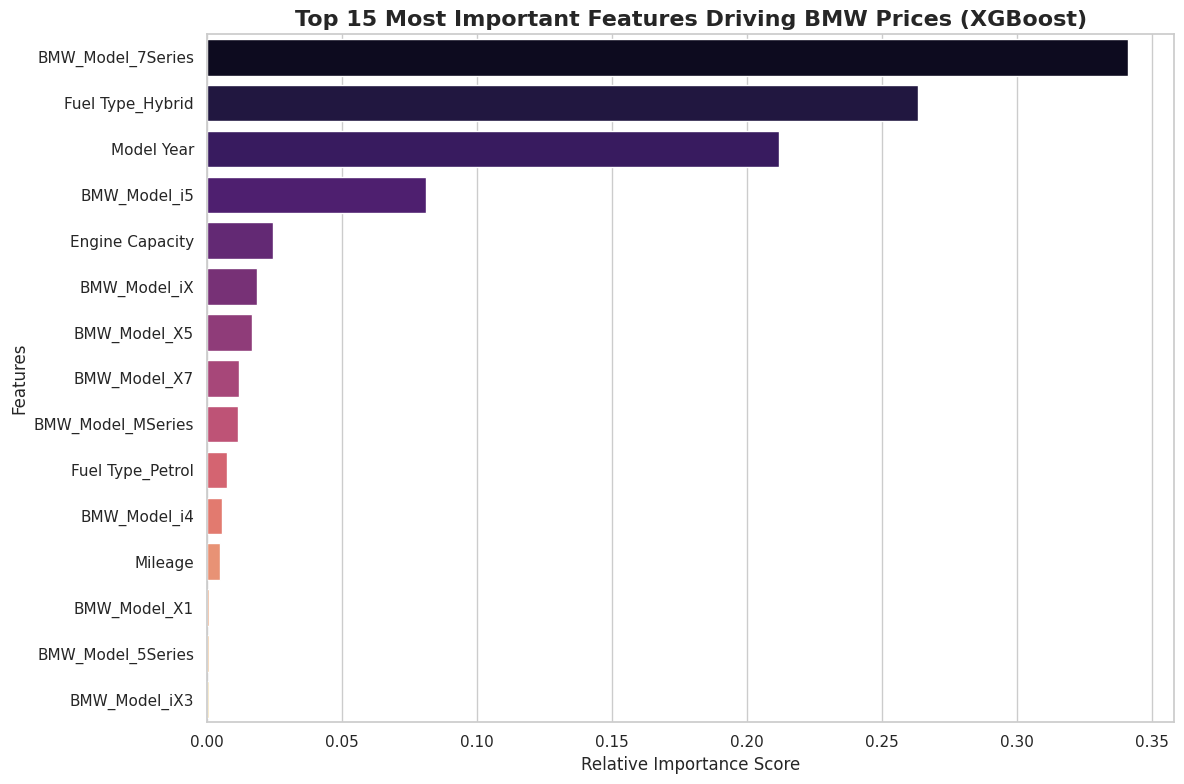

--- Top 5 Features Driving BMW Prices ---
              Feature  Importance
11  BMW_Model_7Series    0.340950
4    Fuel Type_Hybrid    0.263234
0          Model Year    0.211698
19       BMW_Model_i5    0.080956
2     Engine Capacity    0.024192


In [9]:
best_model = models['XGBoost']
feature_importances = best_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature' : X_train.columns,
    'Importance' : feature_importances
})

importance_df = importance_df.sort_values(by = 'Importance', ascending = False)

plt.figure(figsize = (12,8))
sns.barplot(x = 'Importance', y = 'Feature', data = importance_df.head(15), palette = 'magma')

plt.title('Top 15 Most Important Features Driving BMW Prices (XGBoost)', fontsize=16, fontweight='bold')
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("--- Top 5 Features Driving BMW Prices ---")
print(importance_df.head(5))

Hyperparameter Tuning (XGBoost)

In [10]:
from sklearn.model_selection import RandomizedSearchCV


param_grid = {
    'n_estimators' : [100, 200, 300, 400],
    'learning_rate' : [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}

xgb_base = XGBRegressor(random_state = 42)


xgb_random = RandomizedSearchCV(
    estimator = xgb_base,
    param_distributions = param_grid,
    n_iter = 20,
    scoring = 'neg_mean_absolute_error',
    cv = 5,
    verbose = 1,
    random_state = 42,
    n_jobs = -1
)

print("Starting Hyperparameter Tuning. This might take a few seconds...\n")
xgb_random.fit(X_train, y_train)

best_xgb = xgb_random.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"--- Best Hyperparameters Found ---")
for param,value in xgb_random.best_params_.items():
  print(f"{param} : {value}")

print(f"\n--- Tuned Model Performance on Test Set ---")
print(f"Tuned MAE (Millions): {mae_tuned:.4f}")
print(f"Tuned R-squared: {r2_tuned:.4f}")


improvement = evaluation_results['XGBoost']['MAE (Millions)'] - mae_tuned
print(f"\nMAE Improvement: {improvement:.4f} Millions PKR")


Starting Hyperparameter Tuning. This might take a few seconds...

Fitting 5 folds for each of 20 candidates, totalling 100 fits
--- Best Hyperparameters Found ---
subsample : 0.9
n_estimators : 100
max_depth : 6
learning_rate : 0.05
colsample_bytree : 0.9

--- Tuned Model Performance on Test Set ---
Tuned MAE (Millions): 2.2733
Tuned R-squared: 0.9248

MAE Improvement: -0.1751 Millions PKR


 Residual Analysis & Final Predictions

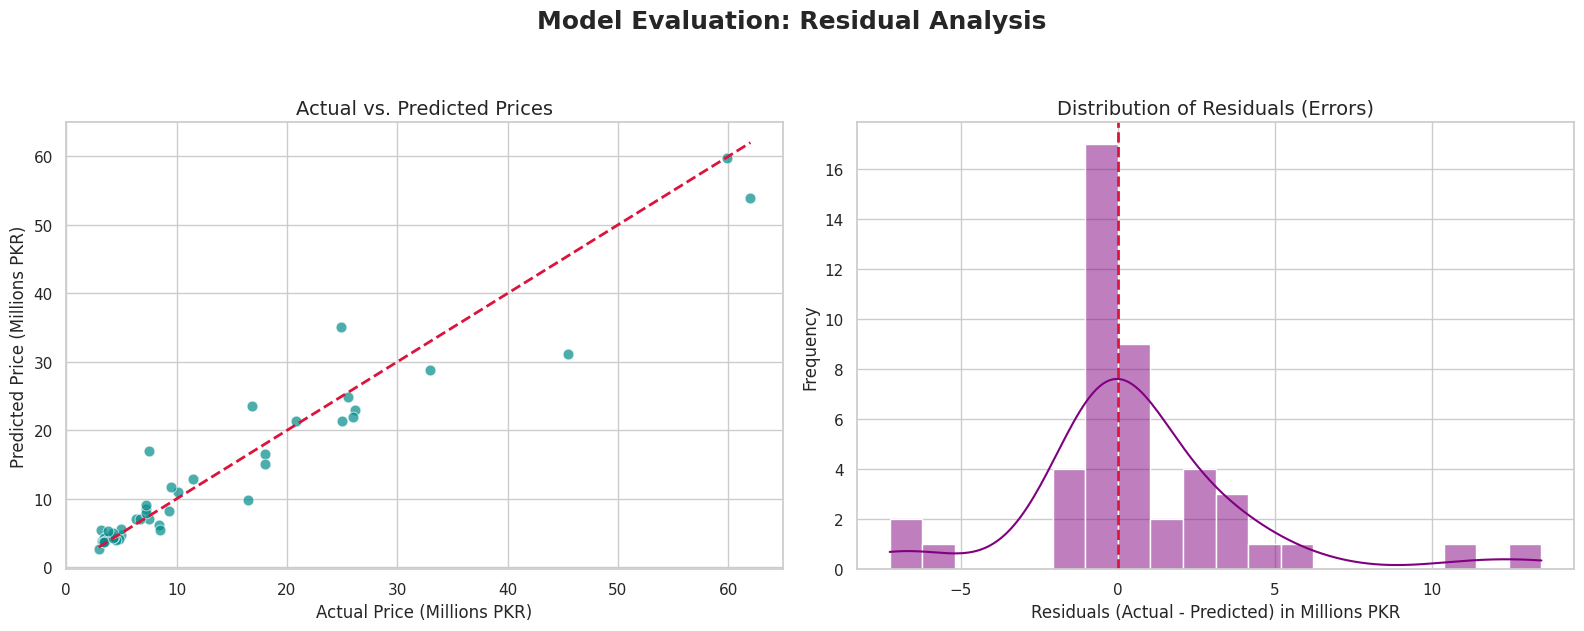

--- Final Model Predictions: A Glimpse ---


,Actual Price (M PKR),Predicted Price (M PKR),Absolute Error (M PKR)
39,11.500,12.960000,2.72
25,3.250,3.870000,0.43
26,16.800,23.520000,2.36
44,3.800,5.290000,0.06
35,9.500,11.790000,0.18
41,4.250,5.000000,0.65
4,10.100,10.940000,1.44
12,7.500,7.010000,0.59
8,4.325,4.410000,0.14
3,18.000,16.610001,0.88


In [11]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize = (16,6))
fig.suptitle('Model Evaluation: Residual Analysis', fontsize=18, fontweight='bold', y=1.05)

sns.scatterplot(x = y_test, y = y_pred_tuned, ax = axes[0], color = 'darkcyan', alpha = 0.7, s = 60)

axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='crimson', linestyle='--', linewidth=2)
axes[0].set_title('Actual vs. Predicted Prices', fontsize=14)
axes[0].set_xlabel('Actual Price (Millions PKR)', fontsize=12)
axes[0].set_ylabel('Predicted Price (Millions PKR)', fontsize=12)

sns.histplot(residuals, kde=True, ax=axes[1], color='purple', bins=20)
axes[1].axvline(x=0, color='crimson', linestyle='--', linewidth=2)
axes[1].set_title('Distribution of Residuals (Errors)', fontsize=14)
axes[1].set_xlabel('Residuals (Actual - Predicted) in Millions PKR', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()
plt.show()

final_comparison = pd.DataFrame({
    'Actual Price (M PKR)': y_test.values,
    'Predicted Price (M PKR)': np.round(y_pred_tuned, 2),
    'Absolute Error (M PKR)': np.round(np.abs(residuals.values), 2)
})

print("--- Final Model Predictions: A Glimpse ---")
display(final_comparison.sample(10, random_state=42))

Model Serialization (Saving for Production)

In [12]:
import joblib
import os

output_dir = 'exported_models'
os.makedirs(output_dir, exist_ok = True)

model_path = os.path.join(output_dir, 'xgboost_bmw_price_model.pkl')
scaler_path = os.path.join(output_dir, 'standard_scaler.pkl')
features_path = os.path.join(output_dir, 'model_features.pkl')

joblib.dump(best_xgb, model_path)

joblib.dump(scaler, scaler_path)

joblib.dump(X_train.columns.tolist(), features_path)

print("--- Deployment Assets Successfully Saved! ---")
print(f"Model saved at: {model_path} (Size: {os.path.getsize(model_path) / 1024:.2f} KB)")
print(f"Scaler saved at: {scaler_path} (Size: {os.path.getsize(scaler_path) / 1024:.2f} KB)")
print(f"Features list saved at: {features_path} (Size: {os.path.getsize(features_path) / 1024:.2f} KB)")
print("\nThe ML Pipeline is now ready for production!")

--- Deployment Assets Successfully Saved! ---
Model saved at: exported_models/xgboost_bmw_price_model.pkl (Size: 257.56 KB)
Scaler saved at: exported_models/standard_scaler.pkl (Size: 0.94 KB)
Features list saved at: exported_models/model_features.pkl (Size: 0.41 KB)

The ML Pipeline is now ready for production!


Interactive Inference Pipeline & Final Demo

In [13]:
def predict_bmw_price(model_year, mileage, engine_capacity, fuel_type, transmission, bmw_model):

  model = joblib.load('/content/exported_models/xgboost_bmw_price_model.pkl')
  scaler = joblib.load('/content/exported_models/standard_scaler.pkl')
  feature_cols = joblib.load('/content/exported_models/model_features.pkl')

  input_df = pd.DataFrame(0, index = [0], columns = feature_cols)

  input_df['Model Year'] = model_year
  input_df['Mileage'] = mileage
  input_df['Engine Capacity'] = engine_capacity

  fuel_col = f'Fuel Type_{fuel_type}'
  if fuel_col in input_df.columns:
    input_df[fuel_col] = 1

  trans_col = f'Transmission_{transmission}'
  if trans_col in input_df.columns:
    input_df[trans_col] = 1

  model_col = f'BMW_Model_{bmw_model}'
  if model_col in input_df.columns:
    input_df[model_col] = 1



  num_cols = ['Model Year', 'Mileage', 'Engine Capacity']
  input_df[num_cols] = scaler.transform(input_df[num_cols])

  pred_millions = model.predict(input_df)[0]
  pred_pkr = pred_millions * 1000000

  return pred_millions, pred_pkr


sample_pred_m, sample_pred_pkr = predict_bmw_price(
    model_year = 2022,
    mileage = 25000,
    engine_capacity = 3000.0,
    fuel_type = 'Hybrid',
    transmission = 'Automatic',
    bmw_model = '7 Series'
)


print("=" * 55)
print("🚗 BMW PRICE PREDICTION TEST RESULT 🚗")
print("=" * 55)
print(f"Vehicle: BMW 7 Series (2022) | Hybrid | 25,000 km")
print(f"Predicted Price (Millions): {sample_pred_m:.2f} Million PKR")
print(f"Predicted Price (Full):     {sample_pred_pkr:,.0f} PKR")
print("=" * 55)

🚗 BMW PRICE PREDICTION TEST RESULT 🚗
Vehicle: BMW 7 Series (2022) | Hybrid | 25,000 km
Predicted Price (Millions): 40.29 Million PKR
Predicted Price (Full):     40,293,648 PKR
